In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Load data and perform basic analysis

In [30]:
df = pd.read_parquet("./datasets/sample/iot23_sample.parquet")
df['label'] = df['label'].str.lower()

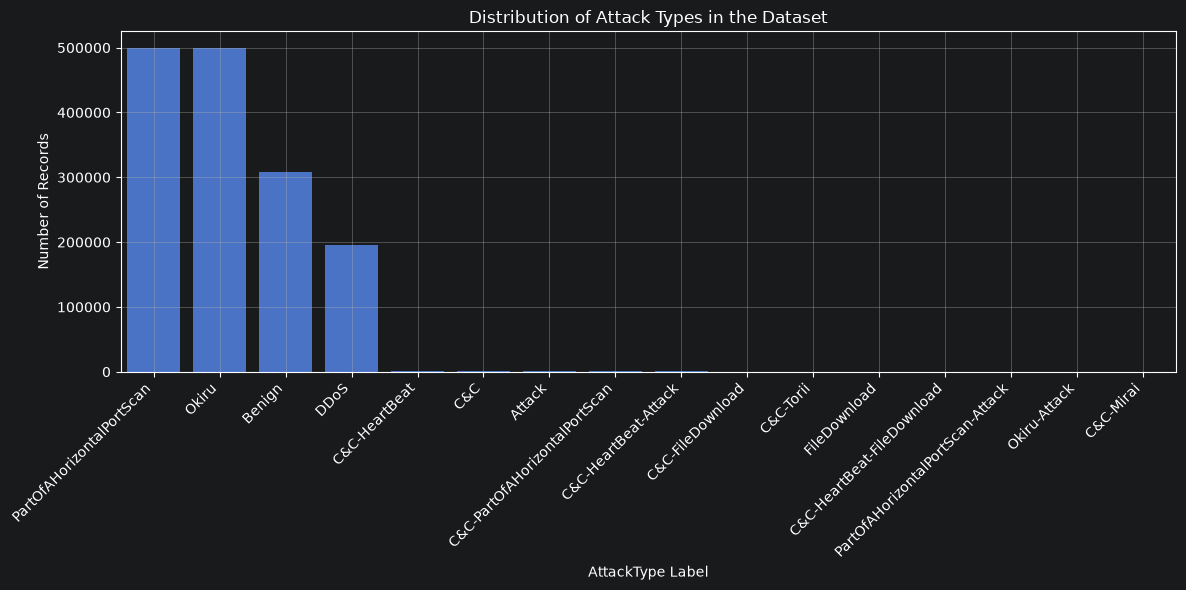

detailed_label
PartOfAHorizontalPortScan           500181
Okiru                               499301
Benign                              307537
DDoS                                195379
C&C-HeartBeat                          992
C&C                                    987
Attack                                 971
C&C-PartOfAHorizontalPortScan          888
C&C-HeartBeat-Attack                   834
C&C-FileDownload                        53
C&C-Torii                               30
FileDownload                            18
C&C-HeartBeat-FileDownload              11
PartOfAHorizontalPortScan-Attack         5
Okiru-Attack                             3
C&C-Mirai                                2
Name: count, dtype: int64


In [31]:
#get distribution
label_counts = df['detailed_label'].value_counts()

#plot
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Attack Types in the Dataset")
plt.xlabel("AttackType Label")
plt.ylabel("Number of Records")
plt.grid(True)
plt.tight_layout()
plt.show()

#shows class ratios
print(label_counts)
df["ts"] = pd.to_datetime(
    df["ts"],
    unit="s",
    utc=True
)

### Check malicious vs benign distribution

In [32]:
df_without_crap = df.drop(columns=["ts", "uid"])
print(df["ts"].head())

malicious: pd.DataFrame = df.groupby("label").get_group("malicious")
benign: pd.DataFrame = df.groupby("label").get_group("benign")

print(f"Malicious: {len(malicious)}")
print(f"Benign: {len(benign)}")

malicious.head()

benign.head()


0   2018-09-06 10:10:03.217796087+00:00
1   2018-09-06 10:10:03.217811108+00:00
2   2018-09-06 10:10:03.673791885+00:00
3   2018-09-06 10:10:04.226730108+00:00
4   2018-09-06 10:10:04.688714981+00:00
Name: ts, dtype: datetime64[ns, UTC]
Malicious: 1199655
Benign: 307537


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,scenario,label,detailed_label
615,2018-09-06 10:11:53.693789005+00:00,CEmNPd1X2QGTCRavqd,63.218.150.243,11.0,192.168.100.111,0.0,icmp,NaN,0.000006,56.0,...,0.0,NaN,2.0,112.0,0.0,0.0,NaN,CTU-IoT-Malware-Capture-17-1,benign,Benign
3131,2018-09-06 11:59:53.973277092+00:00,C9M4Oq4nU60WUFWRqk,192.168.100.111,18088.0,212.211.188.225,8080.0,tcp,NaN,0.055964,0.0,...,0.0,Sr,2.0,80.0,2.0,80.0,NaN,CTU-IoT-Malware-Capture-17-1,benign,Benign
4053,2018-09-06 12:02:55.742991924+00:00,C65qSrvZGj8K5vD72,192.168.100.111,123.0,217.30.75.147,123.0,udp,NaN,0.229375,96.0,...,0.0,Dd,2.0,152.0,2.0,152.0,NaN,CTU-IoT-Malware-Capture-17-1,benign,Benign
4083,2018-10-25 13:14:35.464118958+00:00,C505sa1jNFFexpP6a3,192.168.1.132,40117.0,216.239.35.12,123.0,udp,NaN,0.269349,48.0,...,0.0,Dd,1.0,76.0,1.0,76.0,NaN,CTU-Honeypot-Capture-4-1,benign,Benign
4084,2018-10-25 19:02:04.922314882+00:00,CCzkuS2hJQ2TDX3I98,192.168.1.132,57024.0,52.209.221.67,80.0,tcp,http,0.089698,1847.0,...,0.0,ShADadtfF,7.0,2139.0,7.0,1823.0,NaN,CTU-Honeypot-Capture-4-1,benign,Benign


### Find candidate features

In [33]:
print("\nColumns count:")
print(df.count().sort_values(ascending=True))


is_single_pakket = df["duration"].isnull()
print(f"Single packet flows: {is_single_pakket.sum()}")

has_respones = df["resp_pkts"].apply(lambda x: x > 0)

# source *->1 destination, in timestamp interval 10 minutes? Likely distributed attack, separate on benign or malicious to confirm whether it is based on an attack or not.
amount_of_requests_to_dest = df.groupby(["id.resp_h",pd.Grouper(key="ts", freq="10min")]).size().reset_index(name='count')
amount_of_requests_to_dest = amount_of_requests_to_dest[amount_of_requests_to_dest["count"] > 1200]

amount_of_requests_to_dest_exploration = amount_of_requests_to_dest

amount_of_requests_to_dest_exploration["amount_benign"] = amount_of_requests_to_dest_exploration.apply(lambda x: len(benign[(benign["id.resp_h"] == x["id.resp_h"]) & (benign["ts"] >= x["ts"]) & (benign["ts"] < x["ts"] + pd.Timedelta(minutes=10))]), axis=1)
amount_of_requests_to_dest_exploration["amount_malicious"] = amount_of_requests_to_dest_exploration.apply(lambda x: len(malicious[(malicious["id.resp_h"] == x["id.resp_h"]) & (malicious["ts"] >= x["ts"]) & (malicious["ts"] < x["ts"] + pd.Timedelta(minutes=10))]), axis=1)

print("Amount of requests to destination port: ", amount_of_requests_to_dest_exploration.head(5))


Columns count:
local_orig              0
local_resp              0
service              1068
tunnel_parents      47663
duration           464659
orig_bytes         464659
resp_bytes         464659
history           1506734
ts                1507192
scenario          1507192
resp_ip_bytes     1507192
resp_pkts         1507192
orig_ip_bytes     1507192
orig_pkts         1507192
conn_state        1507192
label             1507192
proto             1507192
id.resp_p         1507192
id.resp_h         1507192
id.orig_p         1507192
id.orig_h         1507192
uid               1507192
missed_bytes      1507192
detailed_label    1507192
dtype: int64
Single packet flows: 1042533
Amount of requests to destination port:                id.resp_h                        ts  count  amount_benign  \
429449   162.248.88.215 2019-09-20 22:20:00+00:00  35660              0   
835694   209.97.190.136 2018-12-22 04:10:00+00:00   8374              0   
893193    216.18.168.16 2018-12-22 10:00:00+00:00   

In [34]:
# source *->1 destination, in timestamp interval 10 minutes? Likely distributed attack, separate on benign or malicious to confirm whether it is based on an attack or not.
amount_of_requests_to_dest = df.groupby(["id.resp_h",pd.Grouper(key="ts", freq="10min")]).size().reset_index(name='count')
amount_of_requests_to_dest = amount_of_requests_to_dest[amount_of_requests_to_dest["count"] > 100]
amount_of_requests_to_dest["amount_benign_requests"] = amount_of_requests_to_dest.apply(lambda x: len(benign[(benign["id.resp_h"] == x["id.resp_h"]) & (benign["ts"] >= x["ts"]) & (benign["ts"] < x["ts"] + pd.Timedelta(minutes=10))]), axis=1)
amount_of_requests_to_dest["amount_malicious_requests"] = amount_of_requests_to_dest.apply(lambda x: len(malicious[(malicious["id.resp_h"] == x["id.resp_h"]) & (malicious["ts"] >= x["ts"]) & (malicious["ts"] < x["ts"] + pd.Timedelta(minutes=10))]), axis=1)

amount_of_requests_to_dest.head(5)

,id.resp_h,ts,count,amount_benign_requests,amount_malicious_requests
100389,123.59.209.185,2018-12-22 08:20:00+00:00,162,0,162
429449,162.248.88.215,2019-09-20 22:20:00+00:00,35660,0,35660
835693,209.97.190.136,2018-12-22 04:00:00+00:00,676,0,676
835694,209.97.190.136,2018-12-22 04:10:00+00:00,8374,0,8374
893193,216.18.168.16,2018-12-22 10:00:00+00:00,2632,0,2632


In [ ]:
features = [df["proto"], df["duration"], df["orig_pkts"], df["resp_pkts"], df["orig_ip_bytes"], df["resp_ip_bytes"],  is_single_pakket, has_respones
            ,df["history"], amount_of_requests_to_dest, df["label"], df["detailed_label"]]

### Train model on features

Prepare features for model training

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier

time_window = df["ts"].dt.floor("1min")
src = df.groupby(["scenario", "id.orig_h", time_window])
features_df = pd.DataFrame({
    "proto": df["proto"].astype("category"),
    "duration": df["duration"],
    "orig_pkts": df["orig_pkts"],
    "resp_pkts": df["resp_pkts"],
    "orig_ip_bytes": df["orig_ip_bytes"],
    "resp_ip_bytes": df["resp_ip_bytes"],
    "is_single_pkt": df["duration"].isna().astype(int),
    "has_response": (df["resp_pkts"] > 0).astype(int),
    "history": df["history"].astype("category"),
    # how many connections are made to the same destination host in a n-minute time_window
    "dst_conn_cnt_in_time_window": df.groupby(["scenario", "id.resp_h", time_window])["uid"].transform("size"),
    # what the source host does in this n-minute time_window (for example scanning or propagation)
    "src_conn_cnt_in_time_window": src["uid"].transform("size"),
    "src_uniq_dst_ip_in_time_window": src["id.resp_h"].transform("nunique"),
    "src_uniq_dst_port_in_time_window": src["id.resp_p"].transform("nunique"),
    "src_no_reply_ratio_in_time_window": (df["resp_pkts"] == 0).groupby([df["scenario"], df["id.orig_h"], time_window]).transform("mean"),
})
y = (df["label"] == "malicious").astype(int)
groups = df["scenario"]

Botnet vs Benign classification with XGBoost

In [38]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(df))
for tr, te in cv.split(features_df, y, groups):
    xgb = XGBClassifier(
        n_estimators=150, max_depth=7, learning_rate=0.1,
        tree_method="hist", enable_categorical=True, eval_metric="aucpr",
        scale_pos_weight=(y.iloc[tr] == 0).sum() / (y.iloc[tr] == 1).sum(),
        random_state=42,
    )
    xgb.fit(features_df.iloc[tr], y.iloc[tr])
    oof[te] = xgb.predict_proba(features_df.iloc[te])[:, 1]

print(f"ROC-AUC: {roc_auc_score(y, oof):.4f} | PR-AUC: {average_precision_score(y, oof):.4f}")
print(classification_report(y, oof > 0.5, target_names=["benign", "botnet"], digits=4))

flagged = pd.Series(oof > 0.5, index=df.index)
print(flagged[y == 1].groupby(df.loc[y == 1, "detailed_label"]).mean().sort_values().round(3))

ROC-AUC: 0.6598 | PR-AUC: 0.8318
              precision    recall  f1-score   support

      benign     0.5381    0.6765    0.5994    307537
      botnet     0.9112    0.8511    0.8801   1199655

    accuracy                         0.8155   1507192
   macro avg     0.7246    0.7638    0.7398   1507192
weighted avg     0.8351    0.8155    0.8229   1507192

detailed_label
Attack                              0.780
PartOfAHorizontalPortScan           0.805
Okiru                               0.839
C&C                                 0.902
FileDownload                        0.944
C&C-FileDownload                    0.962
C&C-HeartBeat                       0.992
DDoS                                0.997
C&C-HeartBeat-Attack                0.999
C&C-HeartBeat-FileDownload          1.000
C&C-Mirai                           1.000
C&C-PartOfAHorizontalPortScan       1.000
C&C-Torii                           1.000
Okiru-Attack                        1.000
PartOfAHorizontalPortScan-Attack    1

Which Botnet attack is it? (C&C, Scanning, Attack)

In [39]:
# Attacks are grouped into three categories: scanning, attack, and C&C.
# Sidenote: C&C is command and control, which is the communication channel between the botnet and the botnet operator.
# So C&C is the most important to detect in our case, because this is a label for botnets
ATTACK = {
    "PartOfAHorizontalPortScan": "scanning", "C&C-PartOfAHorizontalPortScan": "scanning",
    "PartOfAHorizontalPortScan-Attack": "scanning", "Okiru": "scanning", "Okiru-Attack": "scanning",
    "DDoS": "attack", "Attack": "attack", "C&C-HeartBeat-Attack": "attack",
    "C&C": "c2", "C&C-HeartBeat": "c2", "C&C-Torii": "c2", "C&C-Mirai": "c2",
    "C&C-FileDownload": "c2", "C&C-HeartBeat-FileDownload": "c2", "FileDownload": "c2",
}
bot = y == 1
X_bot, groups_bot = features_df[bot], groups[bot]
attack_bot = df.loc[bot, "detailed_label"].map(ATTACK)
assert attack_bot.notna().all(), "new detailed_label not in ATTACKS"

# unique classes and counts for class weighting
classes = np.array(sorted(attack_bot.unique()))
counts = attack_bot.value_counts()

weights = attack_bot.map((counts.max() / counts) ** 0.5)

# Train XGBoost classifier for attack type classification
oof_attack = np.empty(len(attack_bot), dtype=object)
for tr, te in cv.split(X_bot, attack_bot, groups_bot):
    classifier = XGBClassifier(
        n_estimators=150, max_depth=7, learning_rate=0.1,
        tree_method="hist", enable_categorical=True, random_state=42,
    )
    classifier.fit(X_bot.iloc[tr], np.searchsorted(classes, attack_bot.iloc[tr]), sample_weight=weights.iloc[tr])
    oof_attack[te] = classes[classifier.predict(X_bot.iloc[te])]
print(classification_report(attack_bot, oof_attack, digits=4, zero_division=0))

              precision    recall  f1-score   support

      attack     0.9971    0.2755    0.4317    197184
          c2     0.2596    0.9030    0.4033      2093
    scanning     0.8755    0.9958    0.9318   1000378

    accuracy                         0.8772   1199655
   macro avg     0.7107    0.7248    0.5889   1199655
weighted avg     0.8944    0.8772    0.8486   1199655

